# Retail Sales Data - Exploratory Data Analysis

## OASIS INFOBYTE Data Analytics Internship

**Task:** EDA on Retail Sales Data

### Objective
To perform exploratory data analysis on retail sales data to identify
sales trends, customer behaviour, product performance and actionable
business insights.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Initial Data Inspection

First, we inspect the structure, size, data types and missing values
in the dataset.

In [ ]:
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(1000, 9)


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [ ]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [ ]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 2. Descriptive Statistics

Descriptive statistics help us understand the central tendency and
variation of the numerical variables in the dataset.

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
df.mean(numeric_only=True)

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [ ]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [ ]:
df.mode(numeric_only=True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [ ]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [ ]:
print(df["Date"].dtype)

datetime64[us]


In [ ]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

In [ ]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales.head()

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
Name: Total Amount, dtype: int64

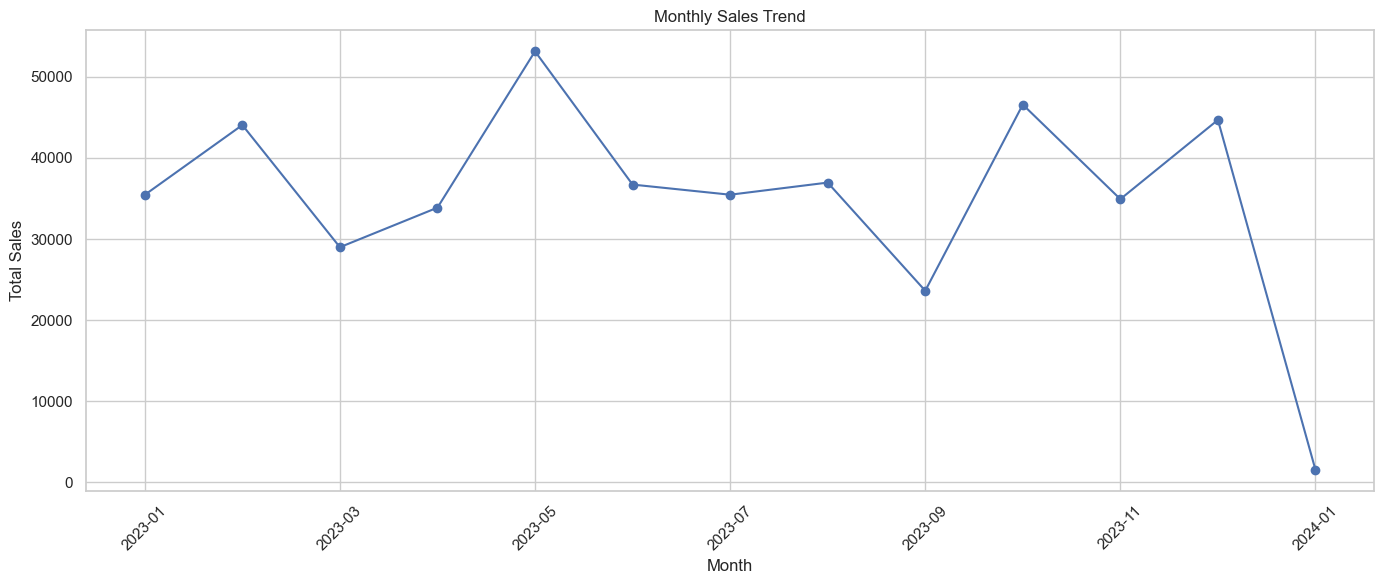

In [ ]:
plt.figure(figsize=(14, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The monthly sales trend shows fluctuations in sales across different
months. The highest sales were observed during ________, while the
lowest sales occurred during ________. This indicates that sales
performance varies over time and may be influenced by seasonal demand.

In [ ]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Name: Total Amount, dtype: int64

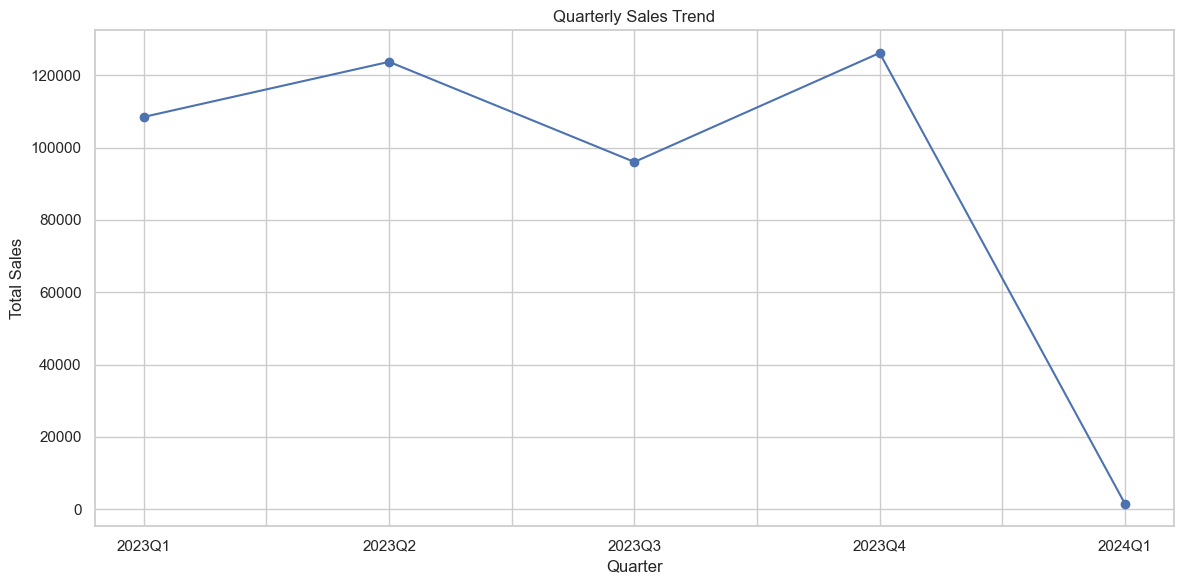

In [ ]:
plt.figure(figsize=(12, 6))

quarterly_sales.plot(kind="line", marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

Quarterly sales show that ________ had the highest overall sales,
while ________ recorded the lowest. The quarterly view helps identify
broader seasonal and business performance patterns.

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=False
)

df["Age Group"].value_counts().sort_index()

Age Group
Under 18      0
18-24       149
25-34       203
35-44       207
45-54       225
55-64       216
65+           0
Name: count, dtype: int64

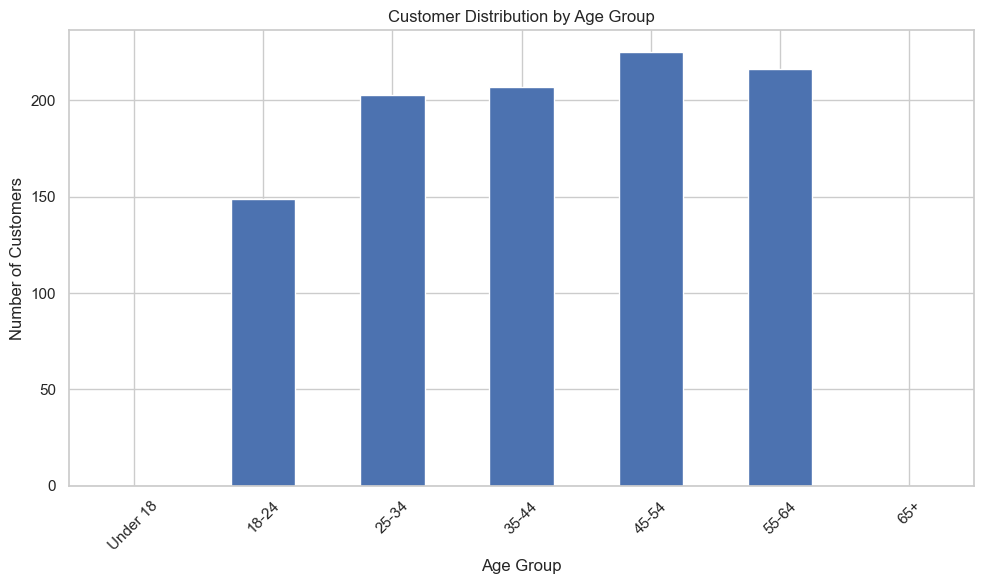

In [ ]:
age_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

age_counts.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The age-group analysis shows that the largest customer group is
__________. This suggests that the business should consider focusing
its marketing strategies on the preferences and purchasing behaviour
of this customer segment.

In [ ]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

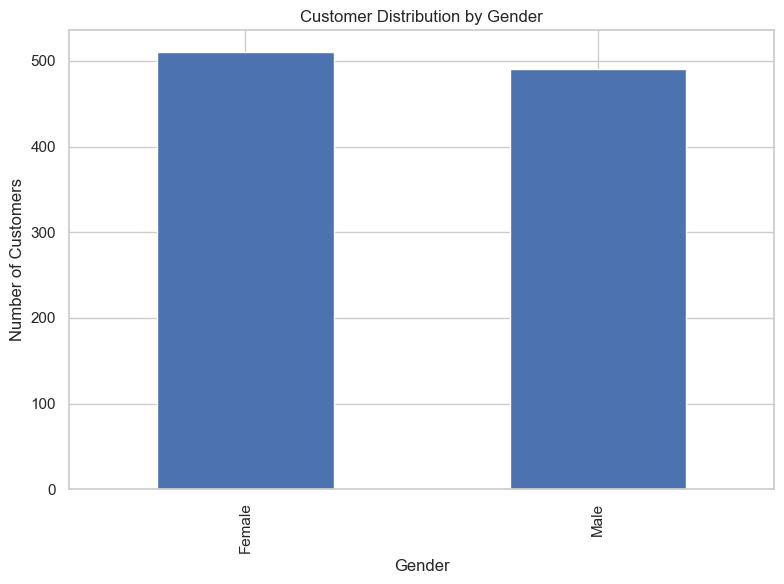

In [ ]:
plt.figure(figsize=(8, 6))

gender_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The gender distribution shows that __________ customers represent
the largest proportion of the dataset. This information can help the
business understand its current customer base and design more targeted
marketing strategies.

In [ ]:
top_products = (
    df.groupby("Product Categoryplt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

In [ ]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

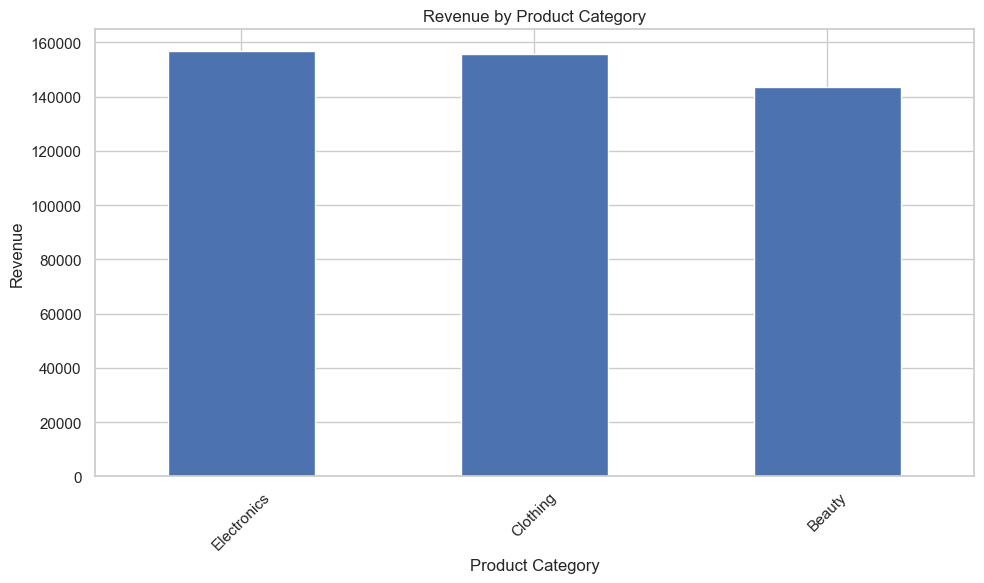

In [ ]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The category analysis shows that __________ generates the highest
revenue, while __________ generates the lowest. The business could
focus on strengthening high-performing categories while identifying
ways to improve weaker categories.

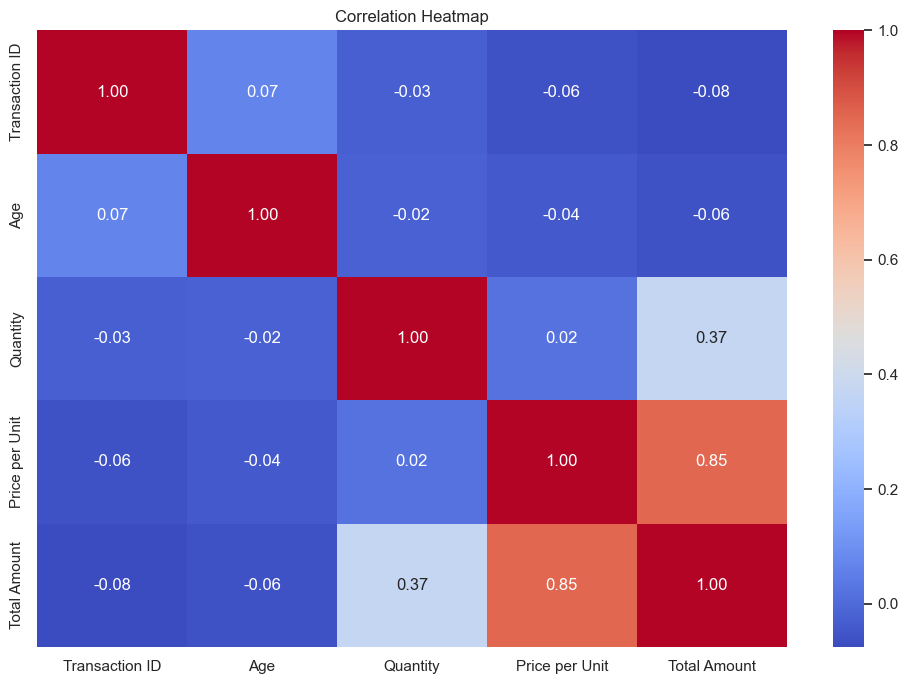

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between the numerical
variables. The strongest positive relationship is between __________
and __________, with a correlation of approximately __________.
This suggests that these variables are closely associated in the
dataset.

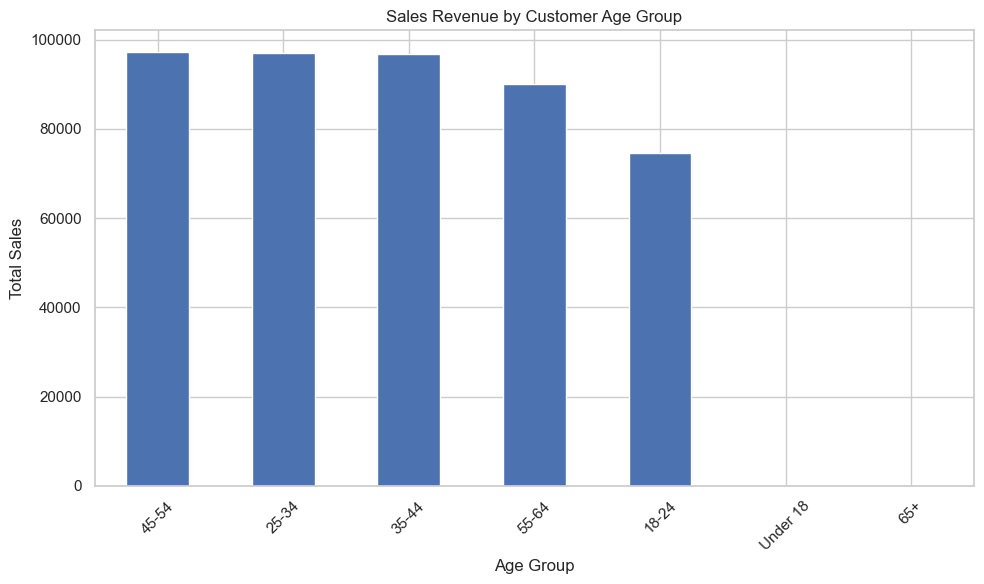

In [ ]:
age_sales = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

age_sales.plot(kind="bar")

plt.title("Sales Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The analysis reveals that the __________ age group contributes the
highest total sales. This indicates that customer age may be useful
for understanding purchasing behaviour and developing targeted
promotional campaigns.

# Conclusion and Business Recommendations

Based on the exploratory data analysis, several important patterns
were identified in sales performance, customer demographics and
product performance."

### Recommendation 1 — Focus on High-Performing Products

The business should maintain sufficient inventory and promotional
support for the top-selling products because these products generate
a significant portion of sales.

### Recommendation 2 — Target the Main Customer Segment

Marketing campaigns should be designed around the age group that
contributes the highest number of customers and/or sales.

### Recommendation 3 — Strengthen High-Revenue Categories

The business should continue investing in high-performing product
categories while analyzing the reasons behind lower-performing
categories and improving their sales strategy.